# Linear Regression Analysis for 2024 Delta Collection


In [1]:
#import relevant libraries
import os
import NLProcessing
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')



#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 20.79it/s]


Numba compilation complete!


In [2]:
#initial file processing
workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\"
specifiedpath = homecomp
openPath = specifiedpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"

In [3]:
#for fonts only
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function Definitions

## Data Loading and Processing for 2024 Format

In [5]:
# Load data from 2024 delta collection where metrics are separated
newfile2024 = openPath + "Compilation with delta\\2024deltagcollection\\"
files2024 = os.listdir(newfile2024)

# Initialize dataframe to store combined data
totalfile_2024 = pd.DataFrame()

# Get unique MBON and responder combinations
mbon_responder_combinations = set()
for filename in files2024:
    if '.csv' in filename:
        # Extract MBON and responder from filename
        # Format: "MBON x RESPONDER dfreg_METRIC .csv"
        parts = filename.replace('.csv', '').split(' ')
        if len(parts) >= 4 and 'dfreg_' in filename:
            mbon = parts[0]
            responder = parts[2]
            mbon_responder_combinations.add((mbon, responder))

print(f"Found {len(mbon_responder_combinations)} MBON x responder combinations")
print(f"Sample combinations: {list(mbon_responder_combinations)[:5]}")

Found 74 MBON x responder combinations
Sample combinations: [('MB310C', 'ACR'), ('MB542B', 'Chrimson2'), ('SS81521', 'Chrimson2'), ('MB323B', 'Chrimson2'), ('SS77424', 'Chrimson2')]


In [6]:
# For each MBON x responder combination, collect all metrics
combined_data = []

for mbon, responder_type in mbon_responder_combinations:
    # Initialize row for this combination
    row_data = {'MBON': mbon, 'responder': responder_type}
    
    # Find all metric files for this combination
    for filename in files2024:
        if filename.startswith(f"{mbon} x {responder_type} dfreg_") and filename.endswith('.csv'):
            # Extract metric name
            metric = filename.split(" ")[3].replace('dfreg_', '').replace('.csv', '').strip()
            
            # Read the file
            filepath = os.path.join(newfile2024, filename)
            try:
                df_metric = pd.read_csv(filepath)
                
                # Extract delta_g value (assuming it's in the 'delta_g' column)
                if 'delta_g' in df_metric.columns and len(df_metric) > 0:
                    delta_g_value = df_metric['delta_g'].iloc[0]  # Take first row's value
                    row_data[f'{metric}_deltag'] = delta_g_value
                    
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                continue
    
    # Only add row if it has metrics
    if len(row_data) > 2:  # More than just MBON and responder
        combined_data.append(row_data)

# Create DataFrame
totalfile_2024 = pd.DataFrame(combined_data)
totalfile_2024['genotypeandresponder'] = totalfile_2024["MBON"] + "_" + totalfile_2024['responder']

print(f"Combined data shape: {totalfile_2024.shape}")
print(f"Columns: {totalfile_2024.columns.tolist()}")
totalfile_2024.head()

Combined data shape: (74, 18)
Columns: ['MBON', 'responder', 'bout_deltag', 'boutpos_deltag', 'bspeed_deltag', 'displacement_deltag', 'displacementbetweenpause_deltag', 'fall_deltag', 'height_deltag', 'maxvelocity_deltag', 'meanbout_deltag', 'meanpause_deltag', 'pause_deltag', 'pausepos_deltag', 'speed_deltag', 'straightindex_deltag', 'time_deltag', 'genotypeandresponder']


,MBON,responder,bout_deltag,boutpos_deltag,bspeed_deltag,displacement_deltag,displacementbetweenpause_deltag,fall_deltag,height_deltag,maxvelocity_deltag,meanbout_deltag,meanpause_deltag,pause_deltag,pausepos_deltag,speed_deltag,straightindex_deltag,time_deltag,genotypeandresponder
0,MB310C,ACR,-0.129,0.149,0.325,0.050,0.385,0.222,0.229,0.262,0.133,0.340,-0.132,0.190,0.043,0.107,0.259,MB310C_ACR
1,MB542B,Chrimson2,-0.268,-0.010,0.355,0.140,0.298,-0.116,0.182,0.757,0.077,0.105,-0.325,0.415,0.129,0.542,-0.022,MB542B_Chrimson2
2,SS81521,Chrimson2,-0.181,-1.000,-0.435,-1.266,-0.929,-0.319,-1.157,-0.594,-1.077,1.031,-0.112,-1.291,-1.280,-0.870,-1.429,SS81521_Chrimson2
3,MB323B,Chrimson2,-0.268,-0.010,0.355,0.140,0.298,-0.116,0.182,0.757,0.077,0.105,-0.325,0.415,0.129,0.542,-0.022,MB323B_Chrimson2
4,SS77424,Chrimson2,-0.268,-0.010,0.355,0.140,0.298,-0.116,0.182,0.757,0.077,0.105,-0.325,0.415,0.129,0.542,-0.022,SS77424_Chrimson2


## Lobe Location Processing

In [7]:
# Get unique MBON list from 2024 data
MBONList_2024 = totalfile_2024['MBON'].unique().tolist()

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation_2024 = pd.DataFrame()

for m in MBONList_2024:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = NLProcessing.find_number(csvfile, m, "Lobe")
    mbonlst = NLProcessing.find_number(csvfile, m, "MBON number").strip()
    ntlst = NLProcessing.find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation_2024 = pd.concat([lobelocation_2024, lobeloc])

lobelocation_2024 = lobelocation_2024.reset_index(drop=True)
print(f"Lobe location data shape: {lobelocation_2024.shape}")
lobelocation_2024.head()

Lobe location data shape: (38, 4)


,MBON,Lobe_location,MBON number,Neurotransmitter
0,MB310C,α1,MBON07,Glutamate
1,MB542B,α2р3р,MBON19,Acetylcholine
2,SS81521,γ4γ5,MBON21,Acetylcholine
3,MB323B,α1,MBON07,Glutamate
4,SS77424,α2sp,MBON23,Acetylcholine


## Linear Regression Analysis - Metric vs Metric

In [8]:
# Select responder type for analysis
responder = "Chrimson2"

# Filter data for selected responder and exclude controls
mbononly_2024 = totalfile_2024[~totalfile_2024['MBON'].isin(['R58', 'Th-Gal4'])]

# Get available metrics (columns ending with '_deltag')
available_metrics = [col for col in totalfile_2024.columns if col.endswith('_deltag')]
print(f"Available metrics: {available_metrics}")

# Select specific metrics for analysis (adapt based on what's available)
# You can modify this list based on what metrics are available in your 2024 data
specificmetrics = ['MBON'] + available_metrics + ['responder', 'genotypeandresponder']

# Create dataframe with specific metrics
eightmetrics_2024 = pd.DataFrame()
for p in specificmetrics:
    if p in mbononly_2024.columns:
        eightmetrics_2024 = pd.concat([eightmetrics_2024, mbononly_2024[p]], axis=1) 
eightmetrics_2024 = eightmetrics_2024.reset_index(drop=True)

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon_2024 = eightmetrics_2024[eightmetrics_2024['responder']=="Chrimson2"]
    if 'bspeed_deltag' in df_specificmbon_2024.columns:
        df_specificmbon_2024 = df_specificmbon_2024.sort_values(by="bspeed_deltag", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon_2024 = eightmetrics_2024[eightmetrics_2024['responder']=="ACR"]
    if 'bspeed_deltag' in df_specificmbon_2024.columns:
        df_specificmbon_2024 = df_specificmbon_2024.sort_values(by="bspeed_deltag", ascending=True).reset_index(drop=True)

print(f"Filtered data shape: {df_specificmbon_2024.shape}")
print(f"Available metrics for regression: {[col for col in df_specificmbon_2024.columns if col.endswith('_deltag')]}")
df_specificmbon_2024.head()


Available metrics: ['bout_deltag', 'boutpos_deltag', 'bspeed_deltag', 'displacement_deltag', 'displacementbetweenpause_deltag', 'fall_deltag', 'height_deltag', 'maxvelocity_deltag', 'meanbout_deltag', 'meanpause_deltag', 'pause_deltag', 'pausepos_deltag', 'speed_deltag', 'straightindex_deltag', 'time_deltag']
Filtered data shape: (37, 18)
Available metrics for regression: ['bout_deltag', 'boutpos_deltag', 'bspeed_deltag', 'displacement_deltag', 'displacementbetweenpause_deltag', 'fall_deltag', 'height_deltag', 'maxvelocity_deltag', 'meanbout_deltag', 'meanpause_deltag', 'pause_deltag', 'pausepos_deltag', 'speed_deltag', 'straightindex_deltag', 'time_deltag']


,MBON,bout_deltag,boutpos_deltag,bspeed_deltag,displacement_deltag,displacementbetweenpause_deltag,fall_deltag,height_deltag,maxvelocity_deltag,meanbout_deltag,meanpause_deltag,pause_deltag,pausepos_deltag,speed_deltag,straightindex_deltag,time_deltag,responder,genotypeandresponder
0,VT999036,0.338,-0.310,-0.897,-1.610,-1.003,-0.138,-0.297,0.326,-1.133,0.873,0.408,-0.559,-1.596,-1.394,-0.479,Chrimson2,VT999036_Chrimson2
1,SS81353,-0.687,-1.638,-0.791,-1.111,-0.608,-0.015,-1.741,-0.653,-0.697,1.608,-0.644,-1.684,-1.097,-1.165,-1.494,Chrimson2,SS81353_Chrimson2
2,SS77450,0.253,-0.150,-0.698,-0.540,-0.692,-0.110,-0.333,-0.315,-0.655,0.153,0.287,-0.359,-0.494,-0.698,-0.307,Chrimson2,SS77450_Chrimson2
3,SS95118,-0.234,0.314,-0.679,-0.822,-0.619,-0.007,0.345,-1.117,-0.111,0.217,-0.157,0.262,-0.778,-0.314,0.262,Chrimson2,SS95118_Chrimson2
4,SS67741,0.294,0.289,-0.662,-0.105,-0.440,0.606,0.284,-1.031,-0.800,-0.118,0.290,0.223,-0.344,-0.481,0.231,Chrimson2,SS67741_Chrimson2


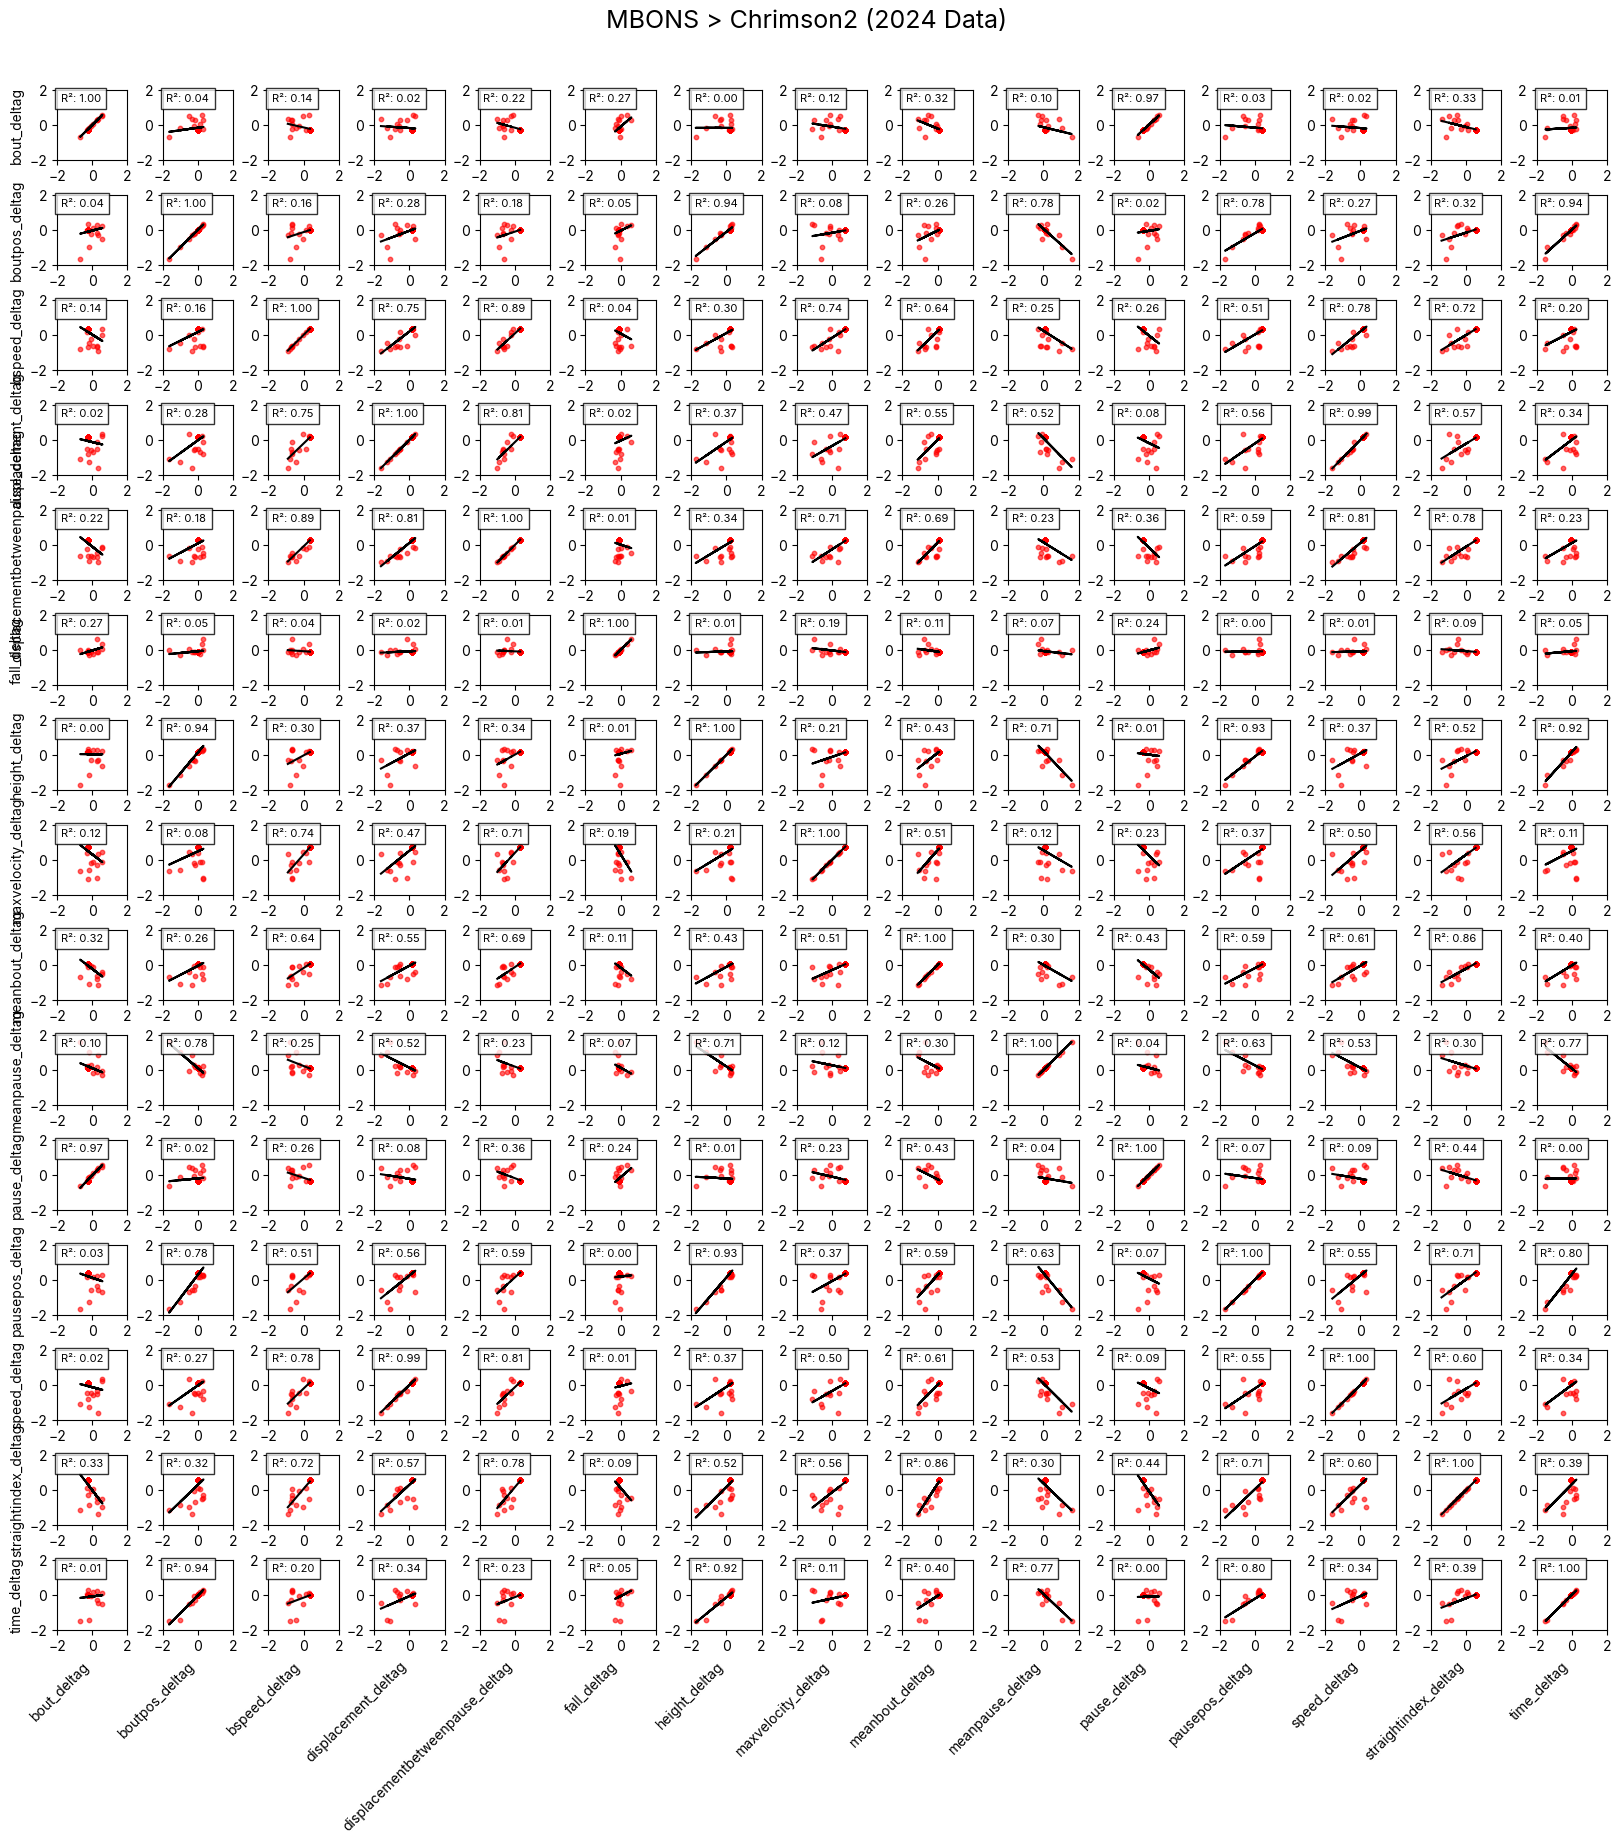

In [9]:
# Create a figure and axis grid for metric vs metric linear regression
from scipy.stats import linregress, pearsonr, t

# Get only the metric columns (ending with '_deltag')
df_linreg_2024 = df_specificmbon_2024[[col for col in df_specificmbon_2024.columns if col.endswith('_deltag')]]
n_metrics = len(df_linreg_2024.columns)

if n_metrics > 1:
    fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(20, 20), gridspec_kw={'wspace': 0.5, 'hspace': 0.5})
    
    # Handle case where we only have 2 metrics (axes would be 1D)
    if n_metrics == 2:
        axes = axes.reshape(2, 2)
    
    # Plot scatter plots for every combination of metrics
    for i in range(n_metrics):
        for j in range(n_metrics):
            ax = axes[i, j]
            x = df_linreg_2024.iloc[:, j]
            y = df_linreg_2024.iloc[:, i]
            
            # Remove NaN values for plotting
            valid_data = pd.DataFrame({'x': x, 'y': y}).dropna()
            if len(valid_data) > 1:
                ax.scatter(valid_data['x'], valid_data['y'], alpha=0.6, c="r", s=10)  # Scatter plot
                
                # Perform linear regression
                slope, intercept, r_value, p_value, std_err = linregress(valid_data['x'], valid_data['y'])
                
                # Add line of best fit
                ax.plot(valid_data['x'], slope * valid_data['x'] + intercept, color='black')  # Regression line
                
                # Annotate with R² value
                ax.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
                        transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                        bbox=dict(facecolor='white', alpha=0.8))
            
            # Set axis labels
            if i == n_metrics-1:  # Add x-axis labels only for the bottom row
                ax.set_xlabel(df_linreg_2024.columns[j], rotation=45, ha='right')
            if j == 0:  # Add y-axis labels only for the first column
                ax.set_ylabel(df_linreg_2024.columns[i])
    
            # Set consistent axis limits
            ax.set_xlim([-2, 2])
            ax.set_ylim([-2, 2])
    
    # Remove empty space between subplots
    plt.tight_layout()
    
    fig.suptitle(f"MBONS > {responder} (2024 Data)", fontsize=18, y=0.92)
    
    # Show the plot
    plt.show()
else:
    print("Need at least 2 metrics for linear regression analysis")

## Single Metric Linear Regression Example

In [ ]:
# Example of single metric vs metric linear regression
# Adapt the metric names based on what's available in your 2024 data

from scipy.stats import linregress

# Select two metrics for comparison (modify these based on available metrics)
metric_cols = [col for col in df_specificmbon_2024.columns if col.endswith('_deltag')]

if len(metric_cols) >= 2:
    x_metric = metric_cols[0]  # First available metric
    y_metric = metric_cols[1]  # Second available metric
    
    # Get data and remove NaN values
    plot_data = df_specificmbon_2024[[x_metric, y_metric]].dropna()
    
    if len(plot_data) > 1:
        x = plot_data[x_metric]
        y = plot_data[y_metric]
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Create the scatter plot
        plt.figure(figsize=(6, 6))
        plt.scatter(x, y, c='g', alpha=0.6, label='Data Points')  # Scatter plot
        
        # Add the line of best fit
        plt.plot(x, slope * x + intercept, color='black', label='Line of Best Fit')  # Regression line
        
        # Annotate with R² value
        plt.text(0.05, 0.95, f"R²: {r_value**2:.2f}\np-value: {p_value:.3f}", 
                 transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', 
                 bbox=dict(facecolor='white', alpha=0.8))
        
        # Add labels and title
        xtitle = x_metric.replace('_deltag', '').replace('_', ' ').title()
        ytitle = y_metric.replace('_deltag', '').replace('_', ' ').title()
        plt.xlabel(f'Δ {xtitle}')
        plt.ylabel(f'Δ {ytitle}')
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.title(f'MBONS > {responder} Line Regression\n{xtitle} vs {ytitle} (2024 Data)', fontsize=12)
        
        # Show the plot
        plt.show()
    else:
        print("Not enough data points for regression analysis")
else:
    print("Need at least 2 metrics for comparison")